# Support Vector Machines

### Table of contents
0. [Introduction](#0.-Introduction)
1. [A tiny dataset, by hand](#1.-A-tiny-dataset,-by-hand)
2. [Setup](#2.-Setup)
3. [Support Vector Machines](#3.-Support-Vector-Machines)
4. [Summary](#4.-Summary)

## 0. Introduction

Notebooks 1 and 2 combined models. This one looks at the boundary differently: SVM picks the widest possible safety margin, not just any separating line.

This is notebook 3 of 5 for the week.

## 1. A tiny dataset, by hand

6 points, 2 classes, cleanly separable.

In [1]:
import numpy as np
from sklearn.svm import SVC

X_svm_toy = np.array([[1., 2.], [2., 1.], [2., 3.], [5., 6.], [6., 5.], [5., 4.]])
y_svm_toy = np.array([0, 0, 0, 1, 1, 1])

svm_toy = SVC(kernel="linear", C=1000).fit(X_svm_toy, y_svm_toy)
svm_toy.support_, svm_toy.support_vectors_

(array([2, 5], dtype=int32),
 array([[2., 3.],
        [5., 4.]]))

Only 2 of the 6 points became support vectors: the ones nearest the other class. `decision_function` confirms they sit closest to the boundary:

In [2]:
svm_toy.decision_function(X_svm_toy)

array([-1.8, -1.4, -1. ,  1.4,  1.8,  1. ])

Move a point that is not a support vector far away and refit. The boundary should not care:

In [3]:
X_moved_non_sv = X_svm_toy.copy()
X_moved_non_sv[0] = [-10., -10.]
svm_moved_non_sv = SVC(kernel="linear", C=1000).fit(X_moved_non_sv, y_svm_toy)
svm_toy.coef_, svm_moved_non_sv.coef_

(array([[0.6, 0.2]]), array([[0.6, 0.2]]))

Identical. Now move one of the two support vectors instead:

In [4]:
X_moved_sv = X_svm_toy.copy()
X_moved_sv[2] = [0., 0.]
svm_moved_sv = SVC(kernel="linear", C=1000).fit(X_moved_sv, y_svm_toy)
svm_toy.coef_, svm_moved_sv.coef_

(array([[0.6, 0.2]]), array([[0.33333333, 0.33333333]]))

Different. That is the entire idea: the boundary is determined only by the support vectors; every other point could move, or vanish, for free.

## 2. Setup

`load_digits`: 1,797 handwritten digit images, 8x8 pixels flattened to 64 features. Split with `stratify=y`, like week 4.

In [5]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

data = load_digits(as_frame=True)
df = data.frame
X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0], " | Test size:", X_test.shape[0])

Train size: 1437  | Test size: 360


And a synthetic 2D dataset for boundary pictures: digits are 64-D and can't be plotted directly, so `make_moons` stands in.

In [6]:
from sklearn.datasets import make_moons
import numpy as np
import matplotlib.pyplot as plt

X_moons, y_moons = make_moons(n_samples=300, noise=0.25, random_state=42)

def plot_boundary(ax, model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], alpha=0.35)
    ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors="white", linewidths=0.6, s=26)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

## 3. Support Vector Machines

If two classes are separable, infinitely many lines can separate them. Which is best?

### 3.1 Maximum margin and support vectors

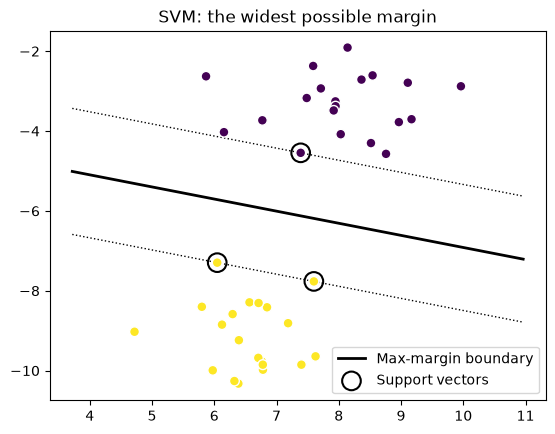

In [7]:
from sklearn.datasets import make_blobs
from sklearn.svm import SVC

X_blobs, y_blobs = make_blobs(n_samples=40, centers=2, cluster_std=0.8, random_state=6)
svm_demo = SVC(kernel="linear", C=1000).fit(X_blobs, y_blobs)

w = svm_demo.coef_[0]
b = svm_demo.intercept_[0]
xx = np.linspace(X_blobs[:, 0].min() - 1, X_blobs[:, 0].max() + 1, 100)
yy = -(w[0] / w[1]) * xx - b / w[1]
margin = 1 / np.sqrt(np.sum(w**2))
offset = np.sqrt(1 + (w[0] / w[1]) ** 2) * margin

plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, edgecolors="white", s=50, zorder=3)
plt.plot(xx, yy, "k-", linewidth=2, label="Max-margin boundary")
plt.plot(xx, yy + offset, "k:", linewidth=1)
plt.plot(xx, yy - offset, "k:", linewidth=1)
plt.scatter(X_blobs[svm_demo.support_, 0], X_blobs[svm_demo.support_, 1],
            s=180, facecolors="none", edgecolors="black", linewidths=1.5, label="Support vectors")
plt.legend()
plt.title("SVM: the widest possible margin")
plt.show()

SVM picks the **widest margin** between classes: more robust to new, noisy points. The **support vectors**, circled above on the margin's edge, are the only points that determine the boundary; everything else could move freely.

### 3.2 Fitting SVM on the real dataset

SVM is distance-based like KNN, so scale matters, though digit pixels already share a 0-16 scale, so it matters less than it did for Breast Cancer.

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_linear = SVC(kernel="linear", C=1.0)
svm_linear.fit(X_train_scaled, y_train)

y_pred_svm_linear = svm_linear.predict(X_test_scaled)
print(f"SVM (linear kernel) test accuracy: {accuracy_score(y_test, y_pred_svm_linear):.4f}")

SVM (linear kernel) test accuracy: 0.9750


Same idea from section 3.1, now at real scale: how many of the 1,437 training points actually became support vectors?

In [9]:
n_sv = svm_linear.n_support_
print("Support vectors per class:", n_sv)
print(f"Total: {n_sv.sum()} of {len(X_train)} training points ({100 * n_sv.sum() / len(X_train):.1f}%)")

Support vectors per class: [29 58 39 41 38 45 27 38 62 52]
Total: 429 of 1437 training points (29.9%)


Roughly a third of the training set, not all of it. Only these points determine the boundary; every other training point could be deleted without changing the model at all.

### 3.3 Kernels: bending the boundary

A linear SVM has the exact same limitation as Logistic Regression: a straight boundary. The **kernel trick** lets SVM behave as if it mapped the data into a richer space where a straight cut becomes possible, without ever actually computing that mapping. `kernel="rbf"` is the standard non-linear choice:

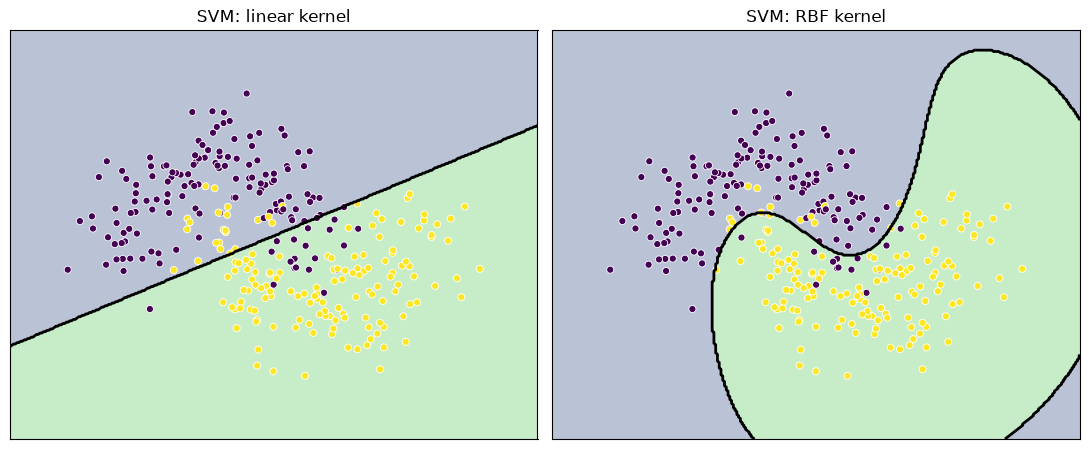

In [10]:
svm_rbf_moons = SVC(kernel="rbf", C=1, gamma="scale").fit(X_moons, y_moons)
svm_linear_moons = SVC(kernel="linear", C=1).fit(X_moons, y_moons)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
plot_boundary(axes[0], svm_linear_moons, X_moons, y_moons, "SVM: linear kernel")
plot_boundary(axes[1], svm_rbf_moons, X_moons, y_moons, "SVM: RBF kernel")
plt.tight_layout()
plt.show()

In [11]:
svm_rbf = SVC(kernel="rbf", C=1, gamma="scale")
svm_rbf.fit(X_train_scaled, y_train)

y_pred_svm_rbf = svm_rbf.predict(X_test_scaled)
print(f"SVM (RBF kernel)    test accuracy: {accuracy_score(y_test, y_pred_svm_rbf):.4f}")

SVM (RBF kernel)    test accuracy: 0.9750


On the moons data the RBF kernel visibly bends around the curve linear can't follow. On the real digits data both kernels do about the same: a synthetic dataset's limitation doesn't always show up on real data.

## 4. Summary

- SVM finds the boundary with the **widest margin**; only the **support vectors** determine it, roughly a third of the training points here.
- Distance-based like KNN: needs scaled features, though how much depends on the raw units.
- The **kernel trick** (`kernel="rbf"`) bends the boundary non-linearly, without transforming the data explicitly.

Notebook 4 covers the last new model this course introduces: Naive Bayes.